0.06631440794043313 -0.07331426824191642
0.35
Target ratio (1/alpha): 0.35
0.06557430744044142 -0.07257408136004176
0.35
Target ratio (1/alpha): 0.35


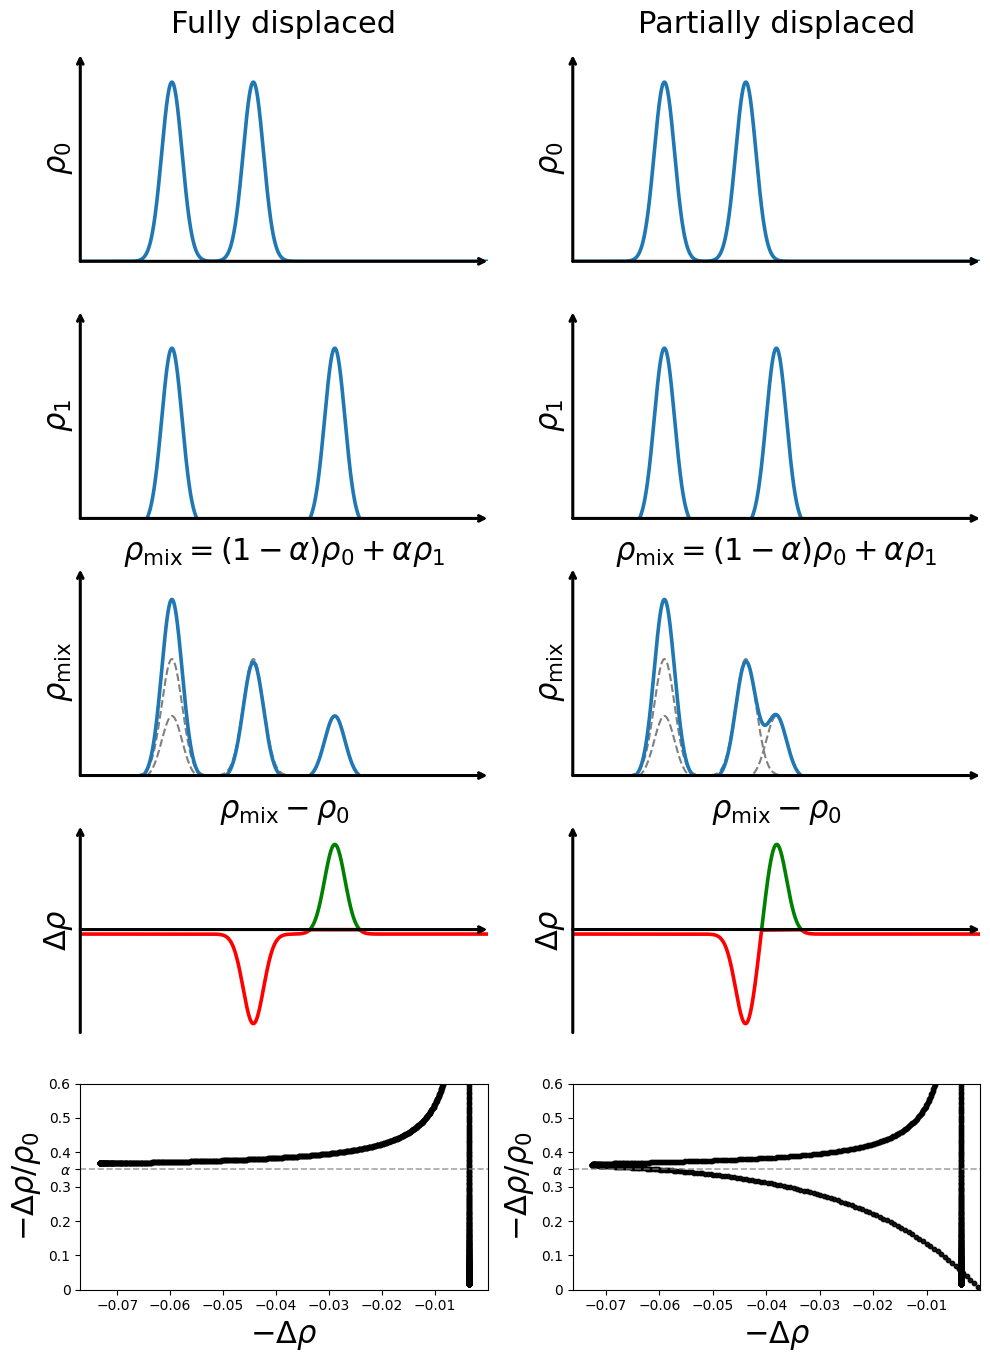

In [1]:
# Re-run the light-mode code (session was reset).
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

LINE_COLOR = "tab:blue"  # single color for all top (line) plots

def gaussian(x, mu, sigma):
    return (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5 * ((x - mu)/sigma)**2)

def style_axes_with_arrows(ax, xlim=None, ylim=None, arrow_color="black"):
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ymin, ymax = ylim
        if ymin == ymax:
            eps = 1e-12 if ymax == 0 else abs(ymax)*1e-6
            ymin -= eps
            ymax += eps
        ax.set_ylim((ymin, ymax))

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    arrowprops = dict(arrowstyle="->", linewidth=2.2, color=arrow_color, shrinkA=0, shrinkB=0)
    if ymin < 0 < ymax:
        ax.annotate("", xy=(xmax, 0), xytext=(xmin, 0), arrowprops=arrowprops)
    else:
        ax.annotate("", xy=(xmax, ymin), xytext=(xmin, ymin), arrowprops=arrowprops)
    if xmin < 0 < xmax:
        ax.annotate("", xy=(0, ymax), xytext=(0, ymin), arrowprops=arrowprops)
    else:
        ax.annotate("", xy=(xmin, ymax), xytext=(xmin, ymin), arrowprops=arrowprops)

def plot_gaussian_mixtures_on_ax(
    axes,
    alpha=0.35,
    mu_common=-6.0,
    mu0_b=2.0,
    mu1_b=5.0,
    sigma=1.0,
    xlim=(0, 40),
    npts=4000,
    yshift=0.0,
    yshift_b=0.0,
    title_kwargs={}
):
    x = np.linspace(xlim[0], xlim[1], npts)

    g_common_0 = gaussian(x, mu_common , sigma)
    g0_b       = gaussian(x, mu0_b   , sigma)

    g_common_1 = gaussian(x, mu_common , sigma)
    g1_b       = gaussian(x, mu1_b     , sigma)

    rho_0  = 0.5 * g_common_0 + 0.5 * g0_b + yshift
    rho_1  = 0.5 * g_common_1 + 0.5 * g1_b + yshift + yshift_b
    alpha2 = 0.15
    rho_mix = alpha2 * rho_1 + (1 - alpha2) * rho_0
    diffmap2 = rho_mix - rho_0
    rho_mix = alpha * rho_1 + (1 - alpha) * rho_0
    diffmap = rho_mix - rho_0

    lw = 2.6
    ymax = rho_0.max()*1.15
    ylim = (yshift, ymax)
    ymin_diff, ymax_diff = diffmap.min(), diffmap.max()
    pad = 0.05 * (abs(ymin_diff) + abs(ymax_diff) + 1e-12)
    ymax_diff = ymax_diff + pad
    ylim_diff = (-ymax, ymax)
    ylim_diff = (ymin_diff - pad, ymax_diff + pad)

    label_kwargs = dict(labelpad=4, fontsize=title_kwargs.get("fontsize",16))
    ax = axes[0]
    ax.plot(x, rho_0, linewidth=lw, color=LINE_COLOR)
    # ax.set_title(r"$\rho_0$", **title_kwargs)
    style_axes_with_arrows(ax, xlim=xlim, ylim=ylim)
    ax.set_ylabel(r"$\rho_0$", **label_kwargs)

    ax = axes[1]
    ax.plot(x, rho_1, linewidth=lw, color=LINE_COLOR)
    # ax.set_title(r"$\rho_1$", **title_kwargs)
    style_axes_with_arrows(ax, xlim=xlim, ylim=ylim)
    ax.set_ylabel(r"$\rho_1$", **label_kwargs)

    ax = axes[2]
    sup_kwargs = dict(linewidth=1.5, color="gray", linestyle="--") 
    ax.plot(x, rho_0*(1-alpha), **sup_kwargs)
    ax.plot(x, rho_1*alpha, **sup_kwargs)
    ax.plot(x, rho_mix, linewidth=lw, color=LINE_COLOR)
    ax.set_title(r"$\rho_{\mathrm{mix}} = (1-\alpha)\rho_0 + \alpha\rho_1$", **title_kwargs)
    style_axes_with_arrows(ax, xlim=xlim, ylim=ylim)
    ax.set_ylabel(r"$\rho_{\mathrm{mix}}$", **label_kwargs)

    ax = axes[3]
    mask = diffmap < 0
    print(np.max(diffmap), np.min(diffmap))
    ax.plot(x[mask], diffmap[mask], linewidth=lw, color="red")
    ax.plot(x[~mask], diffmap[~mask], linewidth=lw, color="green")
    # ax.plot(x, diffmap2, linewidth=lw, color="pink")
    ax.set_title(r"$\rho_{\mathrm{mix}} - \rho_0$", **title_kwargs) 
    style_axes_with_arrows(ax, xlim=xlim, ylim=ylim_diff)
    ax.set_ylabel(r"$\Delta\rho$", **label_kwargs)

    return x, rho_0, rho_1, rho_mix, diffmap

def sci_label(v):
    e = int(np.floor(np.log10(abs(v))))
    m = v / 10**e
    return rf"$10^{e}$" if np.isclose(m, 1) else rf"${m:g}\times10^{e}$"

def plot_mask_scatter(ax, rho_0, diff, alpha, logscale=False, label_kwargs={}):
    """
    Plots a scatter of masked differences with X and Y axes swapped.
    
    X-axis: -rho_0 / diff (Ratio)
    Y-axis: -diff         (Magnitude of difference)
    """
    # 1. Data Preparation
    mask = diff < 0
    
    # Y-axis value (formerly X)
    Y_val = diff[mask]
    # X-axis value (formerly Y)
    inv = True
    if inv:
        X_val = -1/(rho_0[mask] / diff[mask]) 
    else:
        X_val = -(rho_0[mask] / diff[mask]) 
    
    # Threshold for minimum value (to avoid log(0) issues or extreme outliers)
    min_val_threshold = -1e-6 

    # 2. Plotting
    ax.scatter(Y_val,X_val, s=10, alpha=0.9, color="black", label="Data")

    # 3. Axis Configuration
    if inv:
        target_ratio = alpha
    else:
        target_ratio = 1 / alpha

    print("Target ratio (1/alpha):", target_ratio)
    
    if logscale:
        ax.set_xscale("log")
        ax.set_yscale("log")
        
        # Adjust limits based on data presence
        if np.any(Y_val > min_val_threshold):
            # Set X limit based on the max ratio found where Y is significant
            relevant_X = X_val[Y_val > min_val_threshold]
            if len(relevant_X) > 0:
                if inv:
                    ax.set_ylim(None, np.max(1/relevant_X) * 1.1)
                else:
                    ax.set_ylim(None, np.max(relevant_X) * 1.1)
    else:
        # Linear scale specific limits (Swapped logic from original Y-limits)
        # Focused around the target 1/alpha
        if inv:
            ax.set_ylim(0, 1.5 * alpha)
        else:
            ax.set_ylim(0.5 / alpha, 1.5 / alpha)

    # Apply the minimum threshold to the Y-axis (formerly X-axis limit)
    ax.set_xlim(None,min_val_threshold)

    # 4. Labels and Titles
    ax.set_xlabel(r"$-\Delta\rho$", **label_kwargs)
    if inv:
        ax.set_ylabel(r"$-\Delta\rho/\rho_0$", **label_kwargs)
    else:
        ax.set_ylabel(r"$-\rho_0/\Delta\rho$", **label_kwargs)
    # ax.set_title("Background Matching", pad=6)
    ax.grid(False)

    # 5. Target Line (Vertical now)
    ax.axhline(target_ratio, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)

    # 6. Tick Formatting
    # Add the specific target tick to the existing ticks
    current_ticks = ax.get_yticks()
    ax.set_yticks(np.append(current_ticks, target_ratio))

    def get_tick_label(val, pos):
        """
        Custom formatter:
        - Returns '1/α' if the value is close to the target.
        - Returns standard scientific or float formatting otherwise.
        """
        if np.isclose(val, target_ratio):
            return r"$\alpha$"
            return r"$1/\alpha$"
        
        if val == 0:
            return "0"
            
        # Scientific notation logic for logscale legibility
        if logscale:
            exponent = int(np.floor(np.log10(abs(val))))
            mantissa = val / 10**exponent
            if np.isclose(mantissa, 1):
                return rf"$10^{{{exponent}}}$"
            return rf"${mantissa:g}\times 10^{{{exponent}}}$"
        
        # Standard formatting for linear scale
        return f"{val:g}"

    # Apply the formatter to the X-axis (where the 1/alpha ratio now lives)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(get_tick_label))


# Params
alpha      = 0.35
mu_common  = 9.0
mu0_b      = 17.0
sigma      = 1.0

mu1b_values = [25.0, 20.0]
column_titles = ["Fully displaced", "Partially displaced"]
# column_titles = [f"{title}\n\n"+r"$\rho_0$" for title in column_titles]

yshift = +0.01
yshift = -0.01
yshift = -0.

fig, axs = plt.subplots(5, 2, figsize=(10, 14), facecolor="white")
title_kwargs = dict(pad=4, fontsize=22)
label_kwargs = dict(fontsize=22)
diffs = []
for col, (mu1_b, col_title) in enumerate(zip(mu1b_values, column_titles)):
    col_axes = axs[:4, col]
    x, rho0, rho1, rhomix, diff = plot_gaussian_mixtures_on_ax(
        col_axes,
        alpha=alpha,
        mu_common=mu_common,
        mu0_b=mu0_b,
        mu1_b=mu1_b,
        sigma=sigma,
        xlim=(0, 40),
        yshift=yshift,
        yshift_b=-0.01,
        title_kwargs=title_kwargs,
    )
    diffs.append(diff)
    axs[0, col].set_title(col_title, **title_kwargs | {"pad":16})
    print(alpha)
    plot_mask_scatter(axs[4, col], rho0, diff, alpha, label_kwargs=label_kwargs)
# fig.suptitle("Gaussian mixtures: two configurations", color="black", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

0.06981440794043313 -0.06981426824191642
0.06907430744044142 -0.06907408136004176


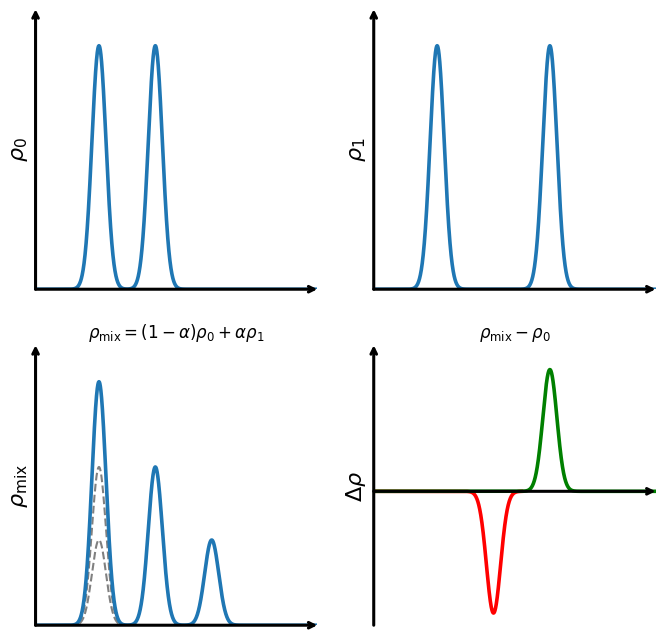

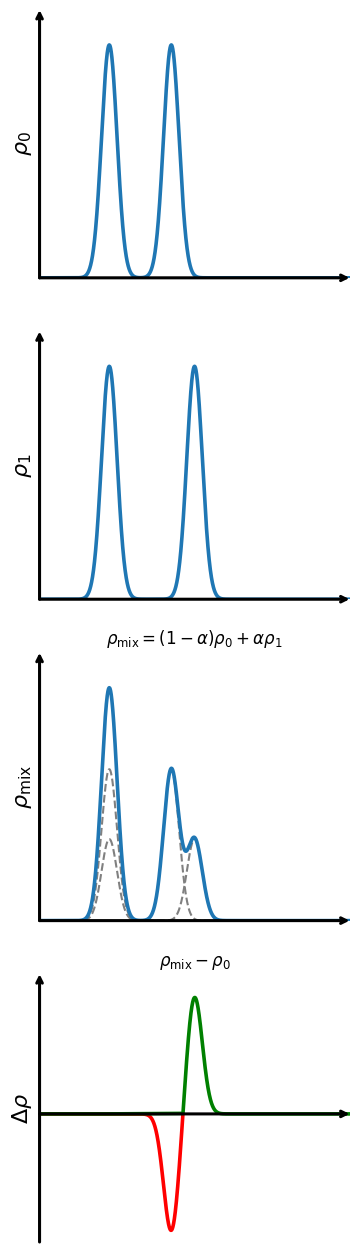

In [2]:
fig, axi = plt.subplots(nrows=2,ncols=2, figsize=(8,8))
ax = axi.flat
x, rho0, rho1, rhomix, diff = plot_gaussian_mixtures_on_ax(
    ax,
    alpha=alpha,
    mu_common=mu_common,
    mu0_b=mu0_b,
    mu1_b=25,
    sigma=sigma,
    xlim=(0, 40),
    yshift=yshift,
    # title_kwargs=title_kwargs,
)

fig, ax = plt.subplots(nrows=4, figsize=(4,16))
x, rho0, rho1, rhomix, diff = plot_gaussian_mixtures_on_ax(
    ax,
    alpha=alpha,
    mu_common=mu_common,
    mu0_b=mu0_b,
    mu1_b=20,
    sigma=sigma,
    xlim=(0, 40),
    yshift=yshift,
    # title_kwargs=title_kwargs,
)


0.06981440794043313 -0.06981426824191642
Target ratio (1/alpha): 0.35
0.06907430744044142 -0.06907408136004176
Target ratio (1/alpha): 0.35
0.06981440794043313 -0.06981426824191642
Target ratio (1/alpha): 0.35


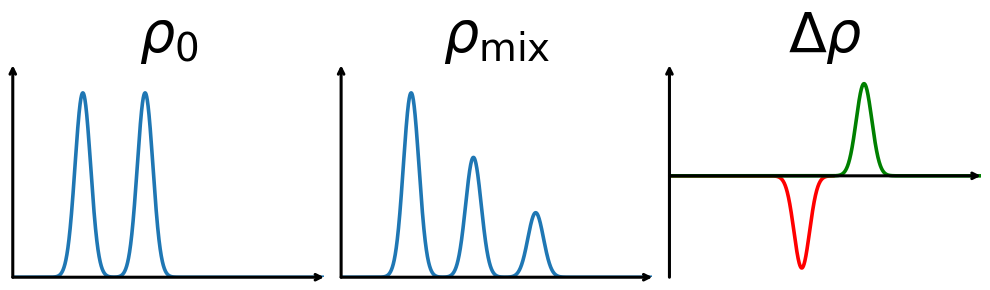

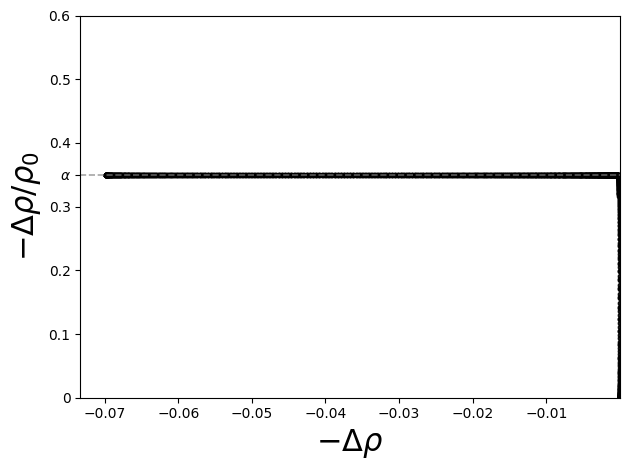

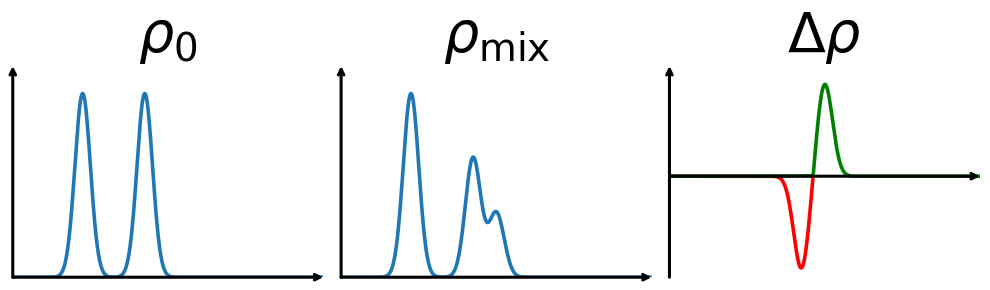

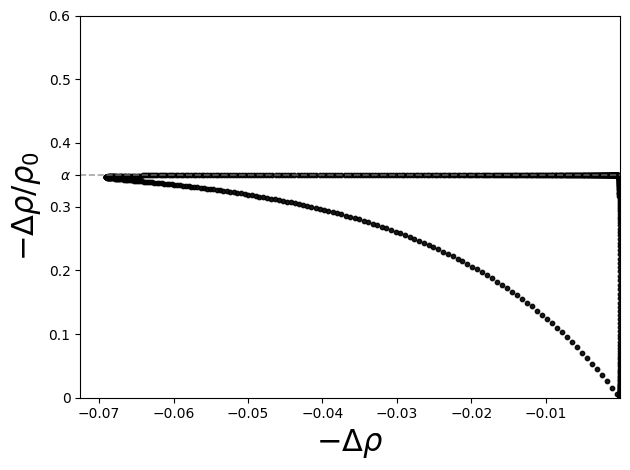

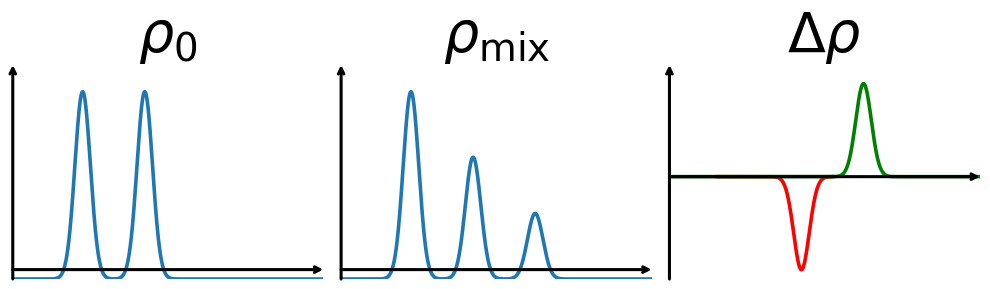

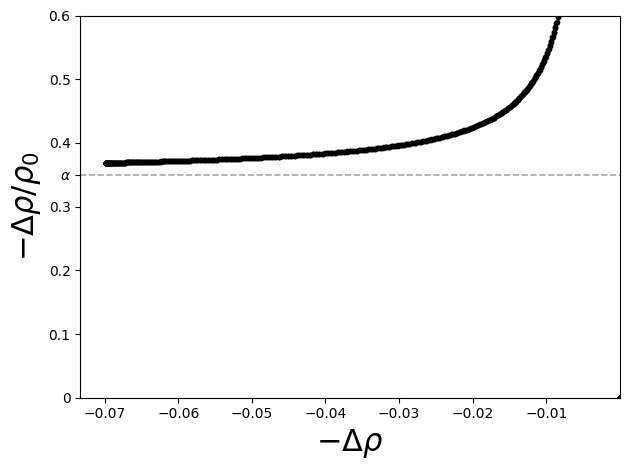

In [ ]:
loc = r"~/Dropbox/Overleaf/App/Occupancy Determination/figs/"
# loc = "/Users/sbielfel/Dropbox/Apps/Overleaf/Occupancy Determination/figs/"
# loc = "../plots/"

# Re-run the light-mode code (session was reset).
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

LINE_COLOR = "tab:blue"  # single color for all top (line) plots

def gaussian(x, mu, sigma):
    return (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5 * ((x - mu)/sigma)**2)

def style_axes_with_arrows(ax, xlim=None, ylim=None, arrow_color="black"):
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ymin, ymax = ylim
        if ymin == ymax:
            eps = 1e-12 if ymax == 0 else abs(ymax)*1e-6
            ymin -= eps
            ymax += eps
        ax.set_ylim((ymin, ymax))

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    arrowprops = dict(arrowstyle="->", linewidth=2.2, color=arrow_color, shrinkA=0, shrinkB=0)
    if ymin < 0 < ymax:
        ax.annotate("", xy=(xmax, 0), xytext=(xmin, 0), arrowprops=arrowprops)
    else:
        ax.annotate("", xy=(xmax, ymin), xytext=(xmin, ymin), arrowprops=arrowprops)
    if xmin < 0 < xmax:
        ax.annotate("", xy=(0, ymax), xytext=(0, ymin), arrowprops=arrowprops)
    else:
        ax.annotate("", xy=(xmin, ymax), xytext=(xmin, ymin), arrowprops=arrowprops)

def plot_gaussian_mixtures_on_ax(
    axes,
    alpha=0.35,
    mu_common=-6.0,
    mu0_b=2.0,
    mu1_b=5.0,
    sigma=1.0,
    xlim=(0, 40),
    npts=4000,
    yshift=0.0,
    title_kwargs={},
    return_fig=False,
):
    x = np.linspace(xlim[0], xlim[1], npts)

    g_common_0 = gaussian(x, mu_common , sigma)
    g0_b       = gaussian(x, mu0_b   , sigma)

    g_common_1 = gaussian(x, mu_common , sigma)
    g1_b       = gaussian(x, mu1_b     , sigma)

    rho_0  = 0.5 * g_common_0 + 0.5 * g0_b + yshift
    rho_1  = 0.5 * g_common_1 + 0.5 * g1_b + yshift
    alpha2 = 0.15
    rho_mix = alpha2 * rho_1 + (1 - alpha2) * rho_0
    diffmap2 = rho_mix - rho_0
    rho_mix = alpha * rho_1 + (1 - alpha) * rho_0
    diffmap = rho_mix - rho_0

    lw = 2.6
    ymax = rho_0.max()*1.15
    ylim = (yshift, ymax)
    ymin_diff, ymax_diff = diffmap.min(), diffmap.max()
    pad = 0.05 * (abs(ymin_diff) + abs(ymax_diff) + 1e-12)
    ymax_diff = ymax_diff + pad
    ylim_diff = (-ymax, ymax)
    ylim_diff = (ymin_diff - pad, ymax_diff + pad)

    label_kwargs = dict(labelpad=4, fontsize=title_kwargs.get("fontsize",25))
    ax = axes[0]
    ax.plot(x, rho_0, linewidth=lw, color=LINE_COLOR)
    # ax.set_title(r"$\rho_0$", **title_kwargs)
    style_axes_with_arrows(ax, xlim=xlim, ylim=ylim)
    ax.set_title(r"$\rho_0$", **title_kwargs)

    ax = axes[1]
    sup_kwargs = dict(linewidth=1.5, color="gray", linestyle="--") 
    sup_0 = rho_0*(1-alpha)
    sup_0  = sup_0 + np.min(rho_mix) - np.min(sup_0)
    sup_1 = rho_1*alpha
    sup_1  = sup_1 + np.min(rho_mix) - np.min(sup_1)
    # ax.plot(x, sup_0, **sup_kwargs)
    # ax.plot(x, sup_1, **sup_kwargs)
    ax.plot(x, rho_mix, linewidth=lw, color=LINE_COLOR)
    ax.set_title(r"$\rho_{\mathrm{mix}} = (1-\alpha)\rho_0 + \alpha\rho_1$", **title_kwargs)
    ax.set_title(r"$\rho_{\mathrm{mix}}$", **title_kwargs)
    # ax.set_ylabel(r"$\rho_{\mathrm{mix}}$", **label_kwargs)
    style_axes_with_arrows(ax, xlim=xlim, ylim=ylim)
    # ax.set_ylabel(r"$\rho_{\mathrm{mix}}$", **label_kwargs)

    ax = axes[2]
    mask = diffmap < 0
    print(np.max(diffmap), np.min(diffmap))
    ax.plot(x[mask], diffmap[mask], linewidth=lw, color="red")
    ax.plot(x[~mask], diffmap[~mask], linewidth=lw, color="green")
    # ax.plot(x, diffmap2, linewidth=lw, color="pink")
    ax.set_title(r"$\rho_{\mathrm{mix}} - \rho_0$", **title_kwargs) 
    ax.set_title(r"$\Delta\rho$", **title_kwargs) 
    # ax.set_ylabel(r"$\Delta\rho$", **label_kwargs)
    style_axes_with_arrows(ax, xlim=xlim, ylim=ylim_diff)
    if return_fig:
        return x, rho_0, rho_1, rho_mix, diffmap, fig

    return x, rho_0, rho_1, rho_mix, diffmap


fig, ax = plt.subplots(nrows=1,ncols=3, figsize=(10,3))
title_kwargs = dict(pad=4, fontsize=40)
yshift = 0.
x, rho_0, rho_1, rho_mix, diffmap, fig = plot_gaussian_mixtures_on_ax(
    ax,
    alpha=alpha,
    mu_common=mu_common,
    mu0_b=mu0_b,
    mu1_b=25,
    sigma=sigma,
    xlim=(0, 40),
    yshift=yshift,
    title_kwargs=title_kwargs,
    return_fig=True,
)
fig.tight_layout()
fig.savefig(loc+"2_atoms_perfect.pdf")
fig, ax = plt.subplots(tight_layout=True)
plot_mask_scatter(ax, rho_0, diffmap, alpha, label_kwargs=label_kwargs)
fig.savefig(loc+"prediction_perfect.pdf")

fig, ax = plt.subplots(nrows=1,ncols=3, figsize=(10,3), tight_layout=True)
x, rho_0, rho_1, rho_mix, diffmap = plot_gaussian_mixtures_on_ax(
    ax,
    alpha=alpha,
    mu_common=mu_common,
    mu0_b=mu0_b,
    mu1_b=20,
    sigma=sigma,
    xlim=(0, 40),
    yshift=yshift,
    title_kwargs=title_kwargs,
)
fig.savefig(loc+"2_atoms_close.pdf")
fig, ax = plt.subplots(tight_layout=True)
plot_mask_scatter(ax, rho_0, diffmap, alpha, label_kwargs=label_kwargs)
fig.savefig(loc+"prediction_close.pdf")

yshift = -0.01
fig, ax = plt.subplots(nrows=1,ncols=3, figsize=(10,3), tight_layout=True)
x, rho_0, rho_1, rho_mix, diffmap = plot_gaussian_mixtures_on_ax(
    ax,
    alpha=alpha,
    mu_common=mu_common,
    mu0_b=mu0_b,
    mu1_b=25,
    sigma=sigma,
    xlim=(0, 40),
    yshift=yshift,
    title_kwargs=title_kwargs,
)
fig.savefig(loc+"2_atoms_mean.pdf")
fig, ax = plt.subplots(tight_layout=True)
# fig.tight_layout()
plot_mask_scatter(ax, rho_0, diffmap, alpha, label_kwargs=label_kwargs)
fig.savefig(loc+"prediction_mean.pdf")

0.06981440794043313 -0.06981426824191642
Target ratio (1/alpha): 0.35
0.06907430744044142 -0.06907408136004176
Target ratio (1/alpha): 0.35
0.06981440794043313 -0.06981426824191642
Target ratio (1/alpha): 0.35
/Users/sbielfel/Dropbox/Apps/Overleaf/Occupancy Determination/figs/gaussian_mixtures_all.pdf


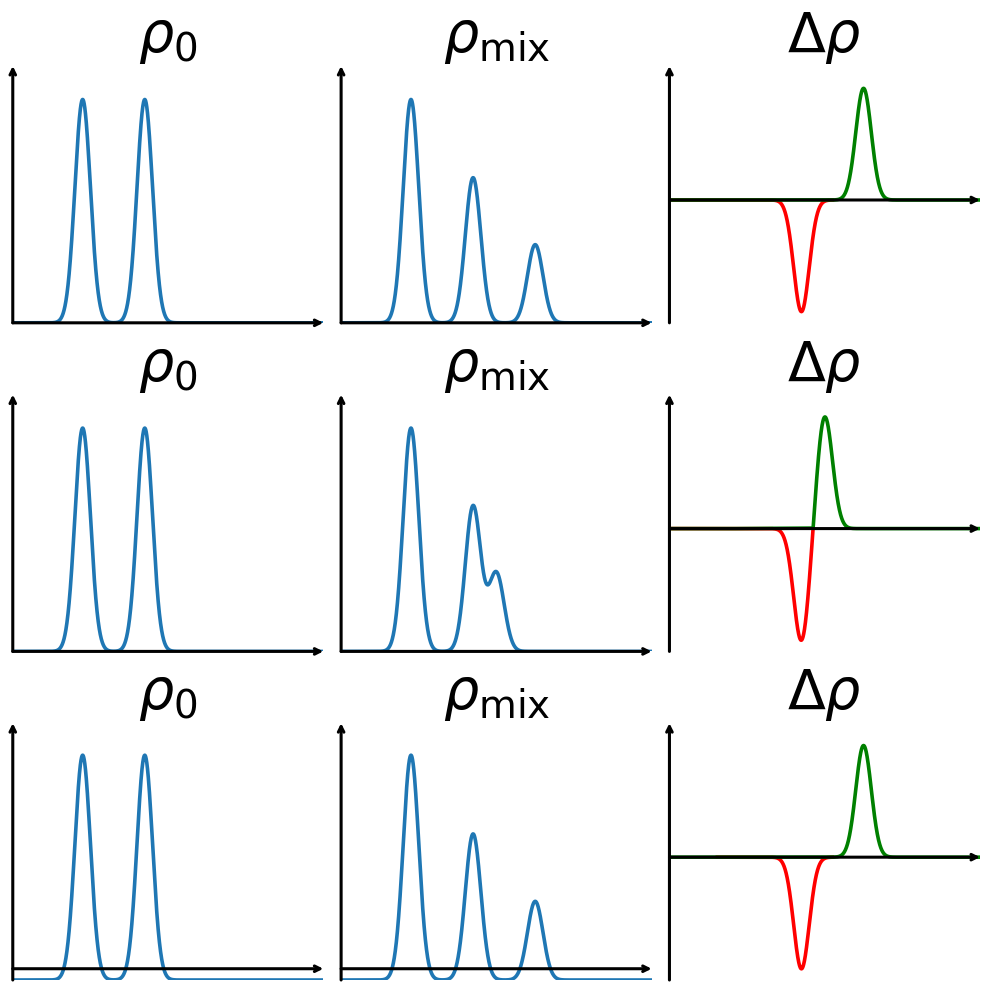

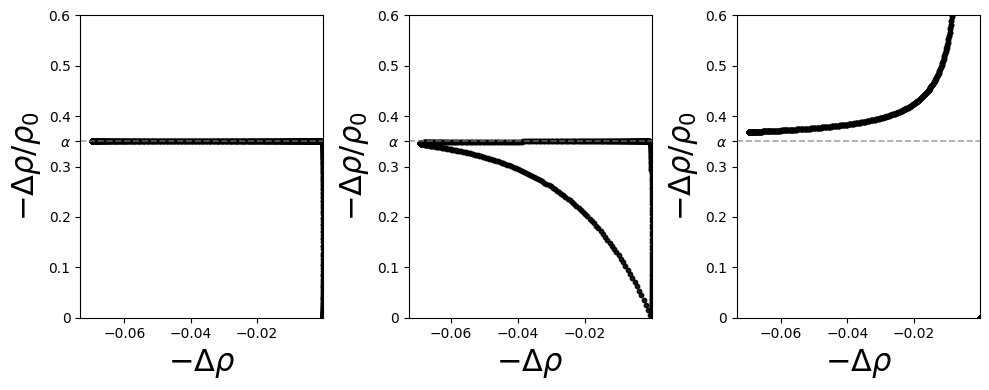

In [7]:
loc = r"~/Dropbox/Overleaf/App/Occupancy Determination/figs/"
loc = "/Users/sbielfel/Dropbox/Apps/Overleaf/Occupancy Determination/figs/"
# loc = "../plots/"

# Re-run the light-mode code (session was reset).
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

LINE_COLOR = "tab:blue"  # single color for all top (line) plots

def gaussian(x, mu, sigma):
    return (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5 * ((x - mu)/sigma)**2)

def style_axes_with_arrows(ax, xlim=None, ylim=None, arrow_color="black"):
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ymin, ymax = ylim
        if ymin == ymax:
            eps = 1e-12 if ymax == 0 else abs(ymax)*1e-6
            ymin -= eps
            ymax += eps
        ax.set_ylim((ymin, ymax))

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    arrowprops = dict(arrowstyle="->", linewidth=2.2, color=arrow_color, shrinkA=0, shrinkB=0)
    if ymin < 0 < ymax:
        ax.annotate("", xy=(xmax, 0), xytext=(xmin, 0), arrowprops=arrowprops)
    else:
        ax.annotate("", xy=(xmax, ymin), xytext=(xmin, ymin), arrowprops=arrowprops)
    if xmin < 0 < xmax:
        ax.annotate("", xy=(0, ymax), xytext=(0, ymin), arrowprops=arrowprops)
    else:
        ax.annotate("", xy=(xmin, ymax), xytext=(xmin, ymin), arrowprops=arrowprops)

def plot_gaussian_mixtures_on_ax(
    axes,
    alpha=0.35,
    mu_common=-6.0,
    mu0_b=2.0,
    mu1_b=5.0,
    sigma=1.0,
    xlim=(0, 40),
    npts=4000,
    yshift=0.0,
    title_kwargs={},
    return_fig=False,
):
    x = np.linspace(xlim[0], xlim[1], npts)

    g_common_0 = gaussian(x, mu_common , sigma)
    g0_b       = gaussian(x, mu0_b   , sigma)

    g_common_1 = gaussian(x, mu_common , sigma)
    g1_b       = gaussian(x, mu1_b     , sigma)

    rho_0  = 0.5 * g_common_0 + 0.5 * g0_b + yshift
    rho_1  = 0.5 * g_common_1 + 0.5 * g1_b + yshift
    alpha2 = 0.15
    rho_mix = alpha2 * rho_1 + (1 - alpha2) * rho_0
    diffmap2 = rho_mix - rho_0
    rho_mix = alpha * rho_1 + (1 - alpha) * rho_0
    diffmap = rho_mix - rho_0

    lw = 2.6
    ymax = rho_0.max()*1.15
    ylim = (yshift, ymax)
    ymin_diff, ymax_diff = diffmap.min(), diffmap.max()
    pad = 0.05 * (abs(ymin_diff) + abs(ymax_diff) + 1e-12)
    ymax_diff = ymax_diff + pad
    ylim_diff = (-ymax, ymax)
    ylim_diff = (ymin_diff - pad, ymax_diff + pad)

    label_kwargs = dict(labelpad=4, fontsize=title_kwargs.get("fontsize",25))
    ax = axes[0]
    ax.plot(x, rho_0, linewidth=lw, color=LINE_COLOR)
    # ax.set_title(r"$\rho_0$", **title_kwargs)
    style_axes_with_arrows(ax, xlim=xlim, ylim=ylim)
    ax.set_title(r"$\rho_0$", **title_kwargs)

    ax = axes[1]
    sup_kwargs = dict(linewidth=1.5, color="gray", linestyle="--") 
    sup_0 = rho_0*(1-alpha)
    sup_0  = sup_0 + np.min(rho_mix) - np.min(sup_0)
    sup_1 = rho_1*alpha
    sup_1  = sup_1 + np.min(rho_mix) - np.min(sup_1)
    # ax.plot(x, sup_0, **sup_kwargs)
    # ax.plot(x, sup_1, **sup_kwargs)
    ax.plot(x, rho_mix, linewidth=lw, color=LINE_COLOR)
    ax.set_title(r"$\rho_{\mathrm{mix}} = (1-\alpha)\rho_0 + \alpha\rho_1$", **title_kwargs)
    ax.set_title(r"$\rho_{\mathrm{mix}}$", **title_kwargs)
    # ax.set_ylabel(r"$\rho_{\mathrm{mix}}$", **label_kwargs)
    style_axes_with_arrows(ax, xlim=xlim, ylim=ylim)
    # ax.set_ylabel(r"$\rho_{\mathrm{mix}}$", **label_kwargs)

    ax = axes[2]
    mask = diffmap < 0
    print(np.max(diffmap), np.min(diffmap))
    ax.plot(x[mask], diffmap[mask], linewidth=lw, color="red")
    ax.plot(x[~mask], diffmap[~mask], linewidth=lw, color="green")
    # ax.plot(x, diffmap2, linewidth=lw, color="pink")
    ax.set_title(r"$\rho_{\mathrm{mix}} - \rho_0$", **title_kwargs) 
    ax.set_title(r"$\Delta\rho$", **title_kwargs) 
    # ax.set_ylabel(r"$\Delta\rho$", **label_kwargs)
    style_axes_with_arrows(ax, xlim=xlim, ylim=ylim_diff)
    if return_fig:
        return x, rho_0, rho_1, rho_mix, diffmap, fig

    return x, rho_0, rho_1, rho_mix, diffmap


fig_all_gauss, ax_all_gauss = plt.subplots(nrows=3,ncols=3, figsize=(10,10), tight_layout=True)
fig_scatter, ax_scatter = plt.subplots(nrows=1,ncols=3, figsize=(10,4), tight_layout=True)
title_kwargs = dict(pad=4, fontsize=40)
yshift = 0.
x, rho_0, rho_1, rho_mix, diffmap, fig = plot_gaussian_mixtures_on_ax(
    ax_all_gauss[0],
    alpha=alpha,
    mu_common=mu_common,
    mu0_b=mu0_b,
    mu1_b=25,
    sigma=sigma,
    xlim=(0, 40),
    yshift=yshift,
    title_kwargs=title_kwargs,
    return_fig=True,
)
plot_mask_scatter(ax_scatter[0], rho_0, diffmap, alpha, label_kwargs=label_kwargs)
x, rho_0, rho_1, rho_mix, diffmap = plot_gaussian_mixtures_on_ax(
    ax_all_gauss[1],
    alpha=alpha,
    mu_common=mu_common,
    mu0_b=mu0_b,
    mu1_b=20,
    sigma=sigma,
    xlim=(0, 40),
    yshift=yshift,
    title_kwargs=title_kwargs,
)
plot_mask_scatter(ax_scatter[1], rho_0, diffmap, alpha, label_kwargs=label_kwargs)

yshift = -0.01
x, rho_0, rho_1, rho_mix, diffmap = plot_gaussian_mixtures_on_ax(
    ax_all_gauss[2],
    alpha=alpha,
    mu_common=mu_common,
    mu0_b=mu0_b,
    mu1_b=25,
    sigma=sigma,
    xlim=(0, 40),
    yshift=yshift,
    title_kwargs=title_kwargs,
)
# fig.tight_layout()
plot_mask_scatter(ax_scatter[2], rho_0, diffmap, alpha, label_kwargs=label_kwargs)

fileloc_gauss = loc+"gaussian_mixtures_all.pdf"
fileloc_scatter = loc+"scatter_all.pdf"
print(fileloc_gauss)
fig_all_gauss.savefig(fileloc_gauss)
fig_scatter.savefig(fileloc_scatter)

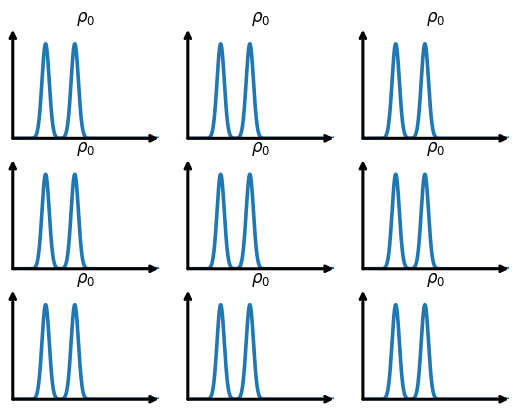

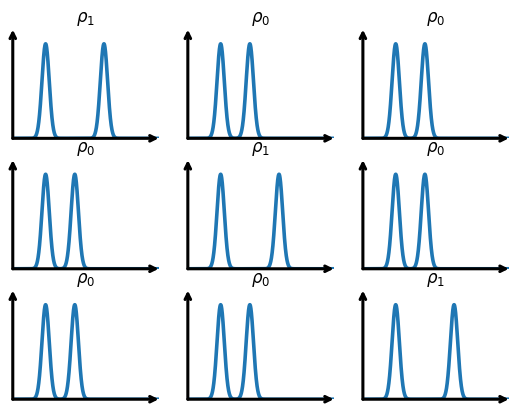

In [19]:

def plot_gaussian_crystal(
    alpha=0.35,
    mu_common=-6.0,
    mu0_b=2.0,
    mu1_b=5.0,
    sigma=1.0,
    xlim=(0, 40),
    npts=4000,
    yshift=0.0,
    title_kwargs={}
):
    x = np.linspace(xlim[0], xlim[1], npts)

    g_common_0 = gaussian(x, mu_common , sigma)
    g0_b       = gaussian(x, mu0_b   , sigma)

    g_common_1 = gaussian(x, mu_common , sigma)
    g1_b       = gaussian(x, mu1_b     , sigma)

    rho_0  = 0.5 * g_common_0 + 0.5 * g0_b + yshift
    rho_1  = 0.5 * g_common_1 + 0.5 * g1_b + yshift
    alpha2 = 0.15
    rho_mix = alpha2 * rho_1 + (1 - alpha2) * rho_0
    diffmap2 = rho_mix - rho_0
    rho_mix = alpha * rho_1 + (1 - alpha) * rho_0
    diffmap = rho_mix - rho_0

    lw = 2.6
    ymax = rho_0.max()*1.15
    ylim = (yshift, ymax)
    ymin_diff, ymax_diff = diffmap.min(), diffmap.max()
    pad = 0.05 * (abs(ymin_diff) + abs(ymax_diff) + 1e-12)
    ymax_diff = ymax_diff + pad
    ylim_diff = (-ymax, ymax)
    ylim_diff = (ymin_diff - pad, ymax_diff + pad)

    label_kwargs = dict(labelpad=4, fontsize=title_kwargs.get("fontsize",25))
    fig, axes = plt.subplots(3,3,)
    for ax in axes.flat:
        ax.plot(x, rho_0, linewidth=lw, color=LINE_COLOR)
        # ax.set_title(r"$\rho_0$", **title_kwargs)
        style_axes_with_arrows(ax, xlim=xlim, ylim=ylim)
        ax.set_title(r"$\rho_0$", **title_kwargs)
    plt.show()
    label_kwargs = dict(labelpad=4, fontsize=title_kwargs.get("fontsize",25))
    fig, axes = plt.subplots(3,3)
    for ax in axes[np.eye(3, dtype=bool)]:
        ax.plot(x, rho_1, linewidth=lw, color=LINE_COLOR)
        # ax.set_title(r"$\rho_0$", **title_kwargs)
        style_axes_with_arrows(ax, xlim=xlim, ylim=ylim)
        ax.set_title(r"$\rho_1$", **title_kwargs)
    for ax in axes[~np.eye(3, dtype=bool)]:
        ax.plot(x, rho_0, linewidth=lw, color=LINE_COLOR)
        # ax.set_title(r"$\rho_0$", **title_kwargs)
        style_axes_with_arrows(ax, xlim=xlim, ylim=ylim)
        ax.set_title(r"$\rho_0$", **title_kwargs)
    plt.show()

plot_gaussian_crystal(
    alpha=alpha,
    mu_common=mu_common,
    mu0_b=mu0_b,
    mu1_b=25,
    sigma=sigma,
    xlim=(0, 40),
    yshift=yshift,
    # title_kwargs=title_kwargs,
)